In [46]:
from Bio import SeqIO
import numpy as np
import matplotlib.pyplot as plt

def strip_insertions(seq):
    return ''.join(c for c in seq if not c.islower())

def plot_msa(a3m_file, dpi=100):


    records = list(SeqIO.parse(a3m_file, "fasta"))


    seqs = [strip_insertions(str(r.seq)) for r in records]

    query = seqs[0]
    L = len(query)
    N = len(seqs)

    query_arr = np.array(list(query))  # (L,)

    # Build the lines array exactly as the repo does:
    # - non-gap positions get the sequence identity value for that row
    # - gap positions get nan (renders as blank)
    msa_arr = np.array([list(seq[:L]) for seq in seqs])  # (N, L)

    gap    = msa_arr != '-'                              # (N, L) bool
    qid    = msa_arr == query_arr[None, :]               # (N, L) bool

    # Mean identity per sequence (only over non-gap positions)
    seqid  = np.where(gap, qid, np.nan)
    seqid  = np.nanmean(seqid, axis=1)                  # (N,)

    # Each cell = seqid of that row if non-gap, else nan
    non_gaps = gap.astype(float)
    non_gaps[non_gaps == 0] = np.nan                     # gaps → nan

    lines = non_gaps * seqid[:, None]                   # (N, L)

    # Sort ascending by seqid so most-identical sits at the top (origin='lower')
    order = seqid.argsort()
    lines = lines[order]

    # Coverage curve (number of non-gap sequences per position)
    coverage = (~np.isnan(lines)).sum(axis=0)

    # -------------------------
    # Plot
    # -------------------------
    fig, ax = plt.subplots(figsize=(12, 5), dpi=100)

    ax.set_title("Sequence Coverage")
    img = ax.imshow(
        lines,
        interpolation='nearest',
        aspect='auto',
        cmap='rainbow_r',
        vmin=0,
        vmax=1,
        origin='lower',
        extent=(0, L, 0, N)
    )

    # Coverage line, scaled to plot height
    ax.plot(coverage, color='black', linewidth=1.5)

    ax.set_xlim(0, L)
    ax.set_ylim(0, N)
    plt.colorbar(img, ax=ax, label="Sequence identity to query")
    ax.set_xlabel("Positions")
    ax.set_ylabel("Sequences")

    plt.tight_layout()
    return plt

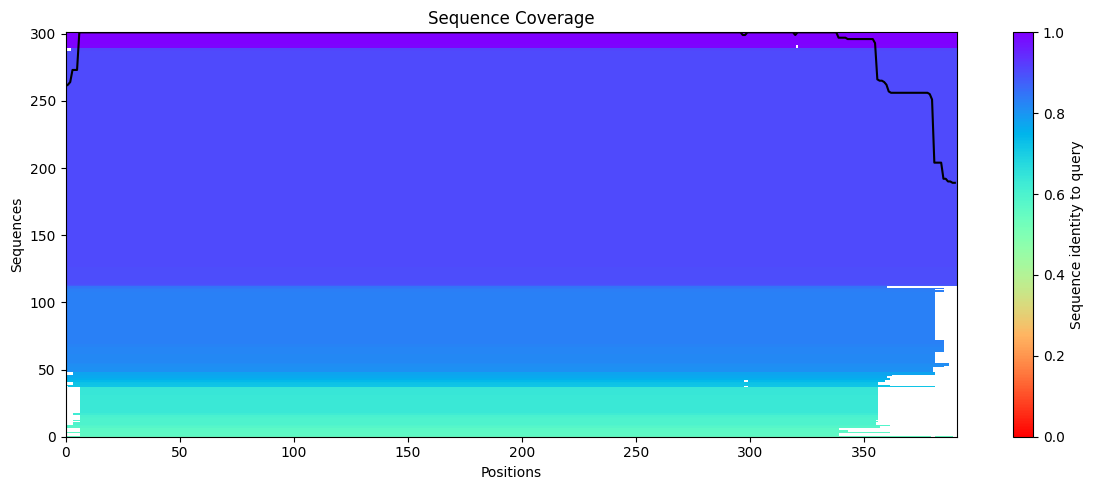

In [48]:
plt=plot_msa('../../mmseqs/outputs/P04529.a3m')
plt.show()

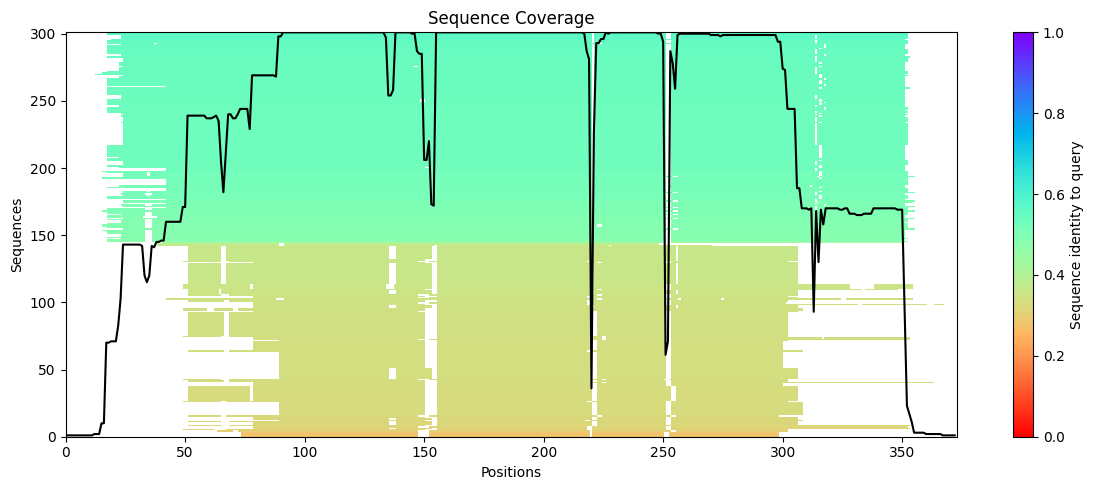

In [49]:
plt=plot_msa('../../mmseqs/outputs/7Z3M.a3m')
plt.show()

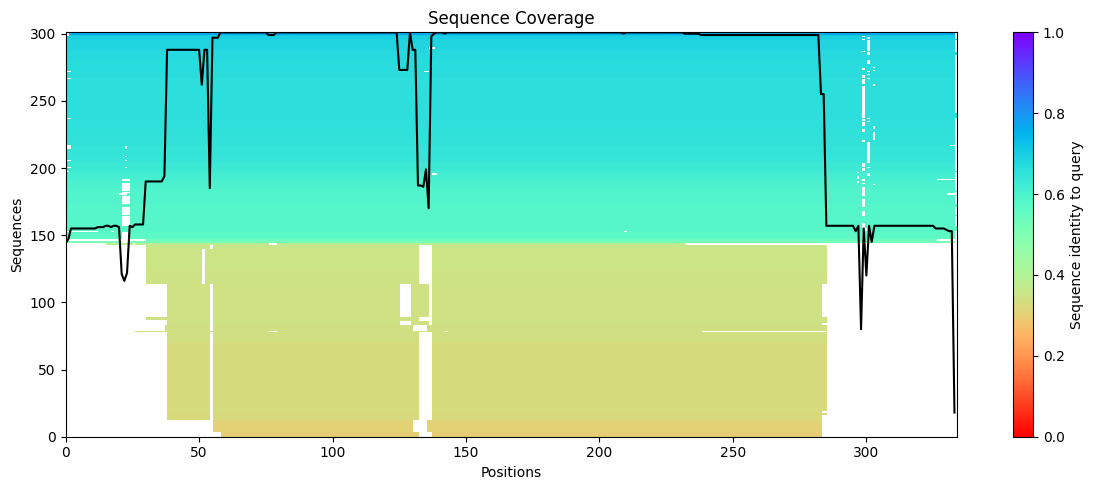

In [50]:
plt=plot_msa('../../mmseqs/outputs/9GBG.a3m')
plt.show()